<h1 style="text-align: center;">
 <strong>Understanding the Impact of State Level Funding on Student Outcomes</strong>
</h1>


<div style="text-align: center;">

## CS 1090A Final Project 
### by: Alex Fernand, Garland Catlette, Grace Augustine, Moniola Odunsi

</div>


<div style="text-align: center;">

As minority students at a predominantly white institution, we have witnessed firsthand the complex ways in which background and identity shape academic experiences and performance. While we have each reached this point through our own individual journeys, we recognize that both our experiences—and those of students like us—are deeply influenced by systemic factors beyond personal effort alone. This project resonated with us because achievement gaps are often framed as the result of individual motivation or ability, rather than the powerful role of structural advantages and disadvantages. Through this project, we aim to better understand how external circumstances shape academic achievement and success.

</div>




## **Table of Contents**
1. Data Description
2. EDA
3. Updates to Variables
4. Research Question
5. Baseline Model


### **Importing Libraries & Packages**


In [104]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample
from scipy.stats import t
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


### **Data Description**


The SID dataset was compiled by researchers from the Albert Shanker Institute, the University of Miami School of Education and Human Development, and the Rutgers University Graduate School of Education. Their goal was to create a comprehensive and credible dataset focusing on district revenue, resource allocation, student performance, and other aspects of school finance across states over nearly 30 years. By collecting data on 125 variables, they produced a dataset that can serve a variety of audiences, including researchers and the general public. The dataset includes state-level measures of equity, spending, salaries, and staffing for each state from 1993 to 2022.


To initially explore this grand data set, we looked at a PDF that included all of the definitions of the variables and identified which ones related to our initial interest in looking at how socioeconomic factors can be related to standardized testing outcomes. The next step was looking at all of the missing values and noticing that for our general standardized testing outcome variable that looks at the gap between the national average and state (*necm_outcomegap_state*) that data collection for this variable only happened between the periods of 2009 and 2019, and was collected for all of the 50 states except Vermont, Alaska, and Hawaii which we excluded from our final filtered data set. Our initial guesses as to why there was no data prior to 2009, testing outcomes were not a socially measured variable, and after 2019, the hit of the COVID-19 pandemic affected this collection because many students were not taking such tests. We then filtered the data to include the socioeconomic factors that we were interested in such as income gaps (to understand how family income plays a role *inc_gap_ratiox*), regions (*state_name*, *region4*, *region 9*) test outcomes by district poverty levels (to understand how district poverty levels play a role *necm_outcome_qx*), a teacher’s salary (how much money is the state allocating to teachers *tch_salaryx_x*), and how much money is actually being allocated per pupil (*necm_ppcstot_state*), and finally staffing per pupil (*fairness_tchph*). It is important to note that our variables that measure funding and outcome gaps, such as *necm_outcomegap_state* and *necm_outcome_qx*, are measured in standard deviations. So, in any further analysis and interpretation, we must think about how to standardize and ensure comparability between our predictors.




In [105]:
df = pd.read_excel("data/StateIndicatorsDatabase_2025.xlsx", sheet_name="Data")

# Filtering data for the years 2009 to 2019 to address missingness
df = df[(df["year"] >= 2009) & (df["year"] <= 2019)]
#df.head()

/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [106]:
predictors_of_interest = ["year", "state_name", "region4", "region9", "necm_ppcstot_state", "necm_fundinggap_state",
 "tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60", "necm_outcomegap_q1", "necm_outcomegap_q2", 
 "necm_outcomegap_q3", "necm_outcomegap_q4", "necm_outcomegap_q5", "fairness_tchph", "inc_gap185_ratio", 
 "inc_gap130_ratio"]
response_var = "necm_outcomegap_state"

#Removed states with missing data for the response variable (Vermont, Alaska, Hawaii)
filtered_df = df[predictors_of_interest + [response_var]].dropna().reset_index(drop=True)
#filtered_df.head()

In the following section, we will explore our response variable and these several predictors to understand any patterns, trends, and relationships that can inform our process in creating our final model!

## Exploratory Data Analysis

_We begin our exploratory analysis by examining a histogram of our response variable, necm_outcomegap_state. The histogram shows that the outcome gap is centered around 0, indicating that, on average, there is no difference between state and national performance across the 10 years of data and the 47 states in our sample. The distribution is tightly clustered around 0, with only a few outliers, suggesting that most observations are only a small number of standard deviations away from the national statewide average test score._

Text(0, 0.5, 'count')

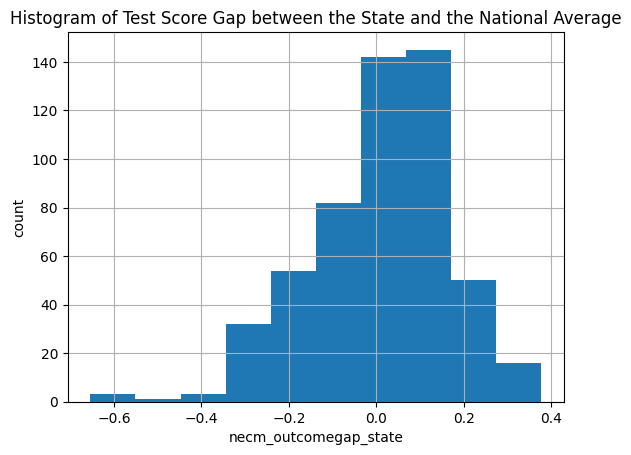

In [107]:
#creating a histogram to explore the distribution of our outcome variable
df['necm_outcomegap_state'].hist()
plt.title("Histogram of Test Score Gap between the State and the National Average") 
plt.xlabel("necm_outcomegap_state")
plt.ylabel("count")

To explore our SID dataset, which pertains to our primary interest in understanding the factors that contribute to gaps in standardized performance, we examined several predictor variables that represent socioeconomic factors. All variables, except for region4, region9, state_name, and year, are continuous. The table below presents summary statistics for all of these predictors. It is important to note that none of our variables contain a significant number of NA values, meaning we do not need to account for missingness, which could otherwise contribute to bias.

We observe that our variables are on very different scales, suggesting that feature scaling may be necessary. For example, some variables are measured in standard deviation–based scales, while others are in dollar amounts. We also see that certain variables, such as *necm_fundinggap_state*, have very large standard deviations, indicating substantial skewness that may affect interpretability. Through further exploration, we will determine whether this variable should be retained in our final model.

In [108]:
#producing a summary table for predictors of interest
summary = pd.DataFrame({
    'NAs'      : filtered_df.isna().sum(),
    'NonNAs'   : filtered_df.notna().sum(),
    'Mean'     : filtered_df.mean(numeric_only=True),
    'Median'   : filtered_df.median(numeric_only=True),
    'STD'      : filtered_df.std(numeric_only=True),
    'IQR'      : filtered_df.quantile(0.75, numeric_only=True) - filtered_df.quantile(0.25, numeric_only=True)
})
summary.index.name = "Figure 1: Summary Statistics of Continous Predictors of Interest"

summary

,NAs,NonNAs,Mean,Median,STD,IQR
Figure 1: Summary Statistics of Continous Predictors of Interest,,,,,,
fairness_tchph,0,517,1.062278,1.040505,0.148055,0.148483
inc_gap130_ratio,0,517,0.194675,0.199068,0.030289,0.034020
inc_gap185_ratio,0,517,0.243414,0.245005,0.034649,0.040210
necm_fundinggap_state,0,517,-209.625479,-420.512100,3844.521952,4686.216000
necm_outcomegap_q1,0,517,0.282291,0.273149,0.225571,0.298808
necm_outcomegap_q2,0,517,0.102992,0.108355,0.213193,0.275957
necm_outcomegap_q3,0,517,0.003604,-0.002099,0.201970,0.299844
necm_outcomegap_q4,0,517,-0.082475,-0.073388,0.198031,0.297626
necm_outcomegap_q5,0,517,-0.301893,-0.298779,0.177266,0.258625


Our correlation coeffiecient heat map shows that several of our current predictors are signficantly correlated (which we define to have coeffieicents of *>0.5*) For example, variables such as the four salary variables are almost perfectly correlated with each other (0.98 - 1.00 correlation), so if we are to keep this variable, we would collapse them into one feature as keeping all four adds no new information. 

Other variables to be concerened about are how inc_gap185_ratio and inc_gap130_ratio are also almost perfectly correlated which means we will only keep one (inc_gap185_ratio) since keeping both adds no new information. Additionally, the outcome gap quintile variables (q1-q5) are highly correlated with our outcome variable necm_outcomegap_state (0.77-0.85), which makes sense since the state average is likely a combination of the quintiles. To avoid predicting the outcome with other variables that are quite similar, we drop these from our predictors. 

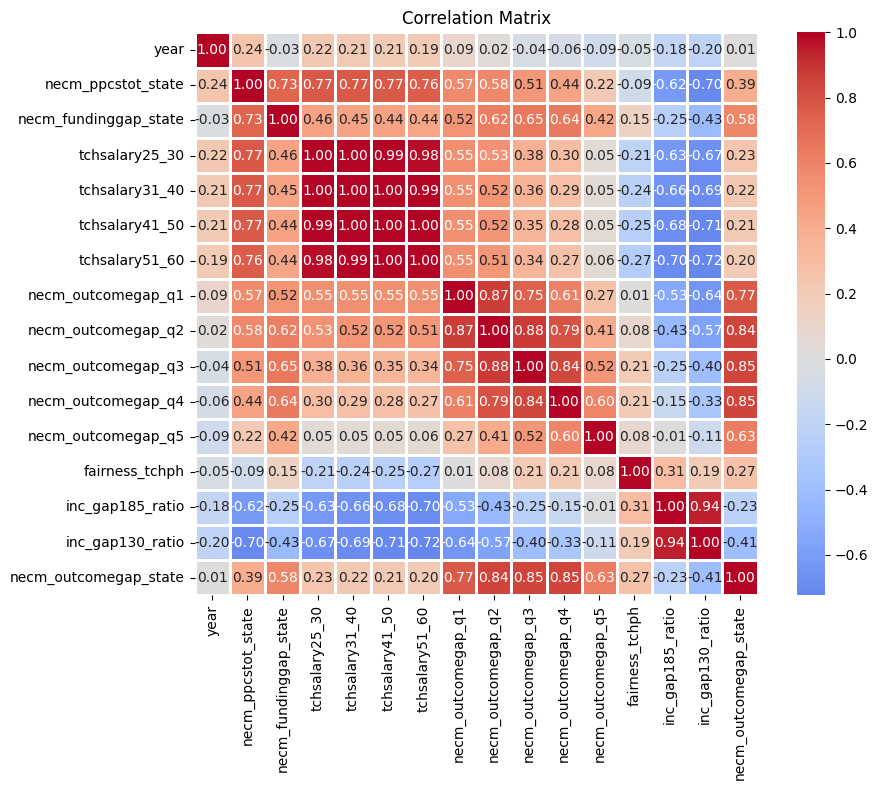

In [109]:
corr_matrix = filtered_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

While looking at the summary and shape of our data is important, we must understand some of the relationships our predictors have with our response variable and with each other. The SID dataset places a very high importance on region, subregion, and states: it's present in how variables are calculated and how the data is collected. So to understand this important feature of our data, we made some noteworthy observations about our regions, subregions, and states. 
The bar chart below shows a striking observation on how the difference between test score gaps from the national average, depending on region, differs. We see that the Midwest and Northeast and their respective subregions (East North Central, West North Central, Mid Atlantic, and New England) all have standard deviations above the National average, while other regions have shown to perform standard deviations below the National Average. 

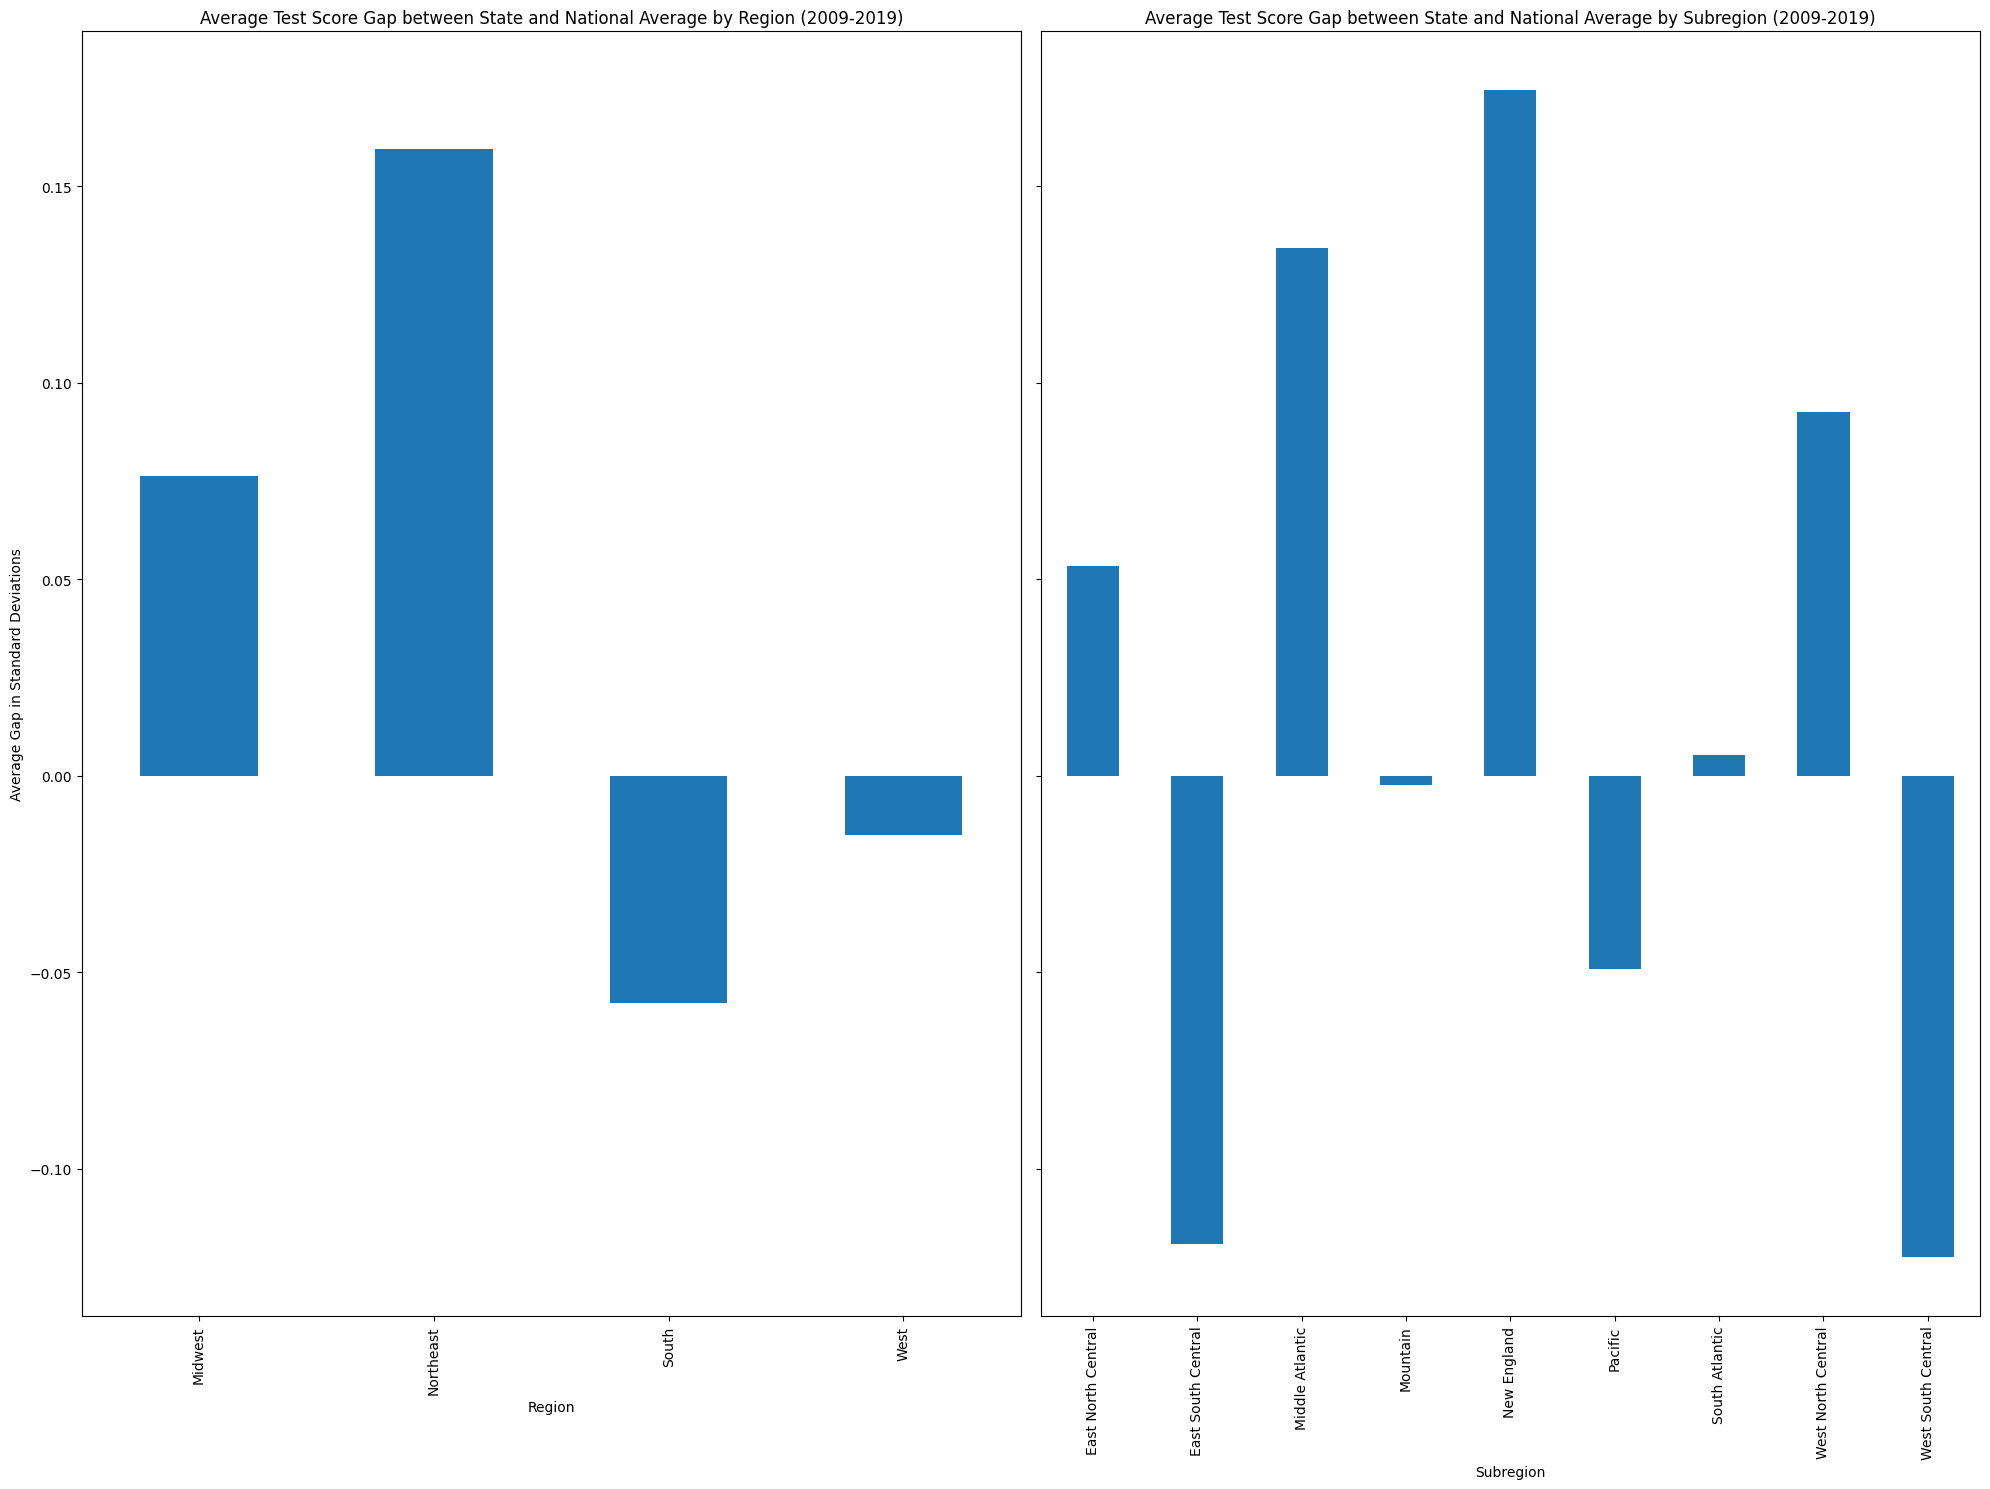

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")[response_var].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Test Score Gap between State and National Average by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average Gap in Standard Deviations")

filtered_df.groupby("region9")[response_var].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Test Score Gap between State and National Average by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average Gap in Standard Deviations")
plt.tight_layout()
plt.show()

We see a trend of the Midwest and the Northeast having standard deviations higher than the national average in terms of funding gaps.


### **Updating Predictors, Feature Engineering, & Splitting Data**

Based on the EDA, we should make a few key feature adjustments. First, it's best to aggregate the four teacher salary variables into a single avg_tchsalary measure, since they are extremely highly correlated. We also drop inc_gap130_ratio due to its high corrleation with inc_gap185_ratio. In addition, we remove the outcome gap quintiles as predictors because they are essentially proxies for the outcome variable.

In [111]:
filtered_df["avg_tchsalary"] = filtered_df[["tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60"]].mean(axis=1)
predictors_of_interest = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary", "region9"]

Given the visualizations above, it is clear that region is a significant predictor, so we apply one-hot encoding to account for its categorical structure and for proper interpretation and modeling.

In [112]:
X_pred = filtered_df[predictors_of_interest]
X_pred = pd.get_dummies(X_pred, columns=["region9"])

#Rename new columns created by get_dummies for clarity
X_pred.columns = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary",
                  "east_north_central", "east_south_central", "mid_atlantic", "mountain", "new_england",
                  "pacific", "south_atlantic", "west_north_central", "west_south_central"]
X_pred.head()

,necm_fundinggap_state,fairness_tchph,inc_gap185_ratio,avg_tchsalary,east_north_central,east_south_central,mid_atlantic,mountain,new_england,pacific,south_atlantic,west_north_central,west_south_central
0,-5113.8250,0.911271,0.242321,28505.1200,False,True,False,False,False,False,False,False,False
1,-2852.4060,0.945713,0.243701,29168.4775,False,False,False,True,False,False,False,False,False
2,-3977.7690,1.210944,0.256912,31957.6500,False,False,False,False,False,False,False,False,True
3,-1159.8540,0.990620,0.203774,42087.2400,False,False,False,False,False,True,False,False,False
4,32.1782,1.146207,0.208257,28357.1500,False,False,False,True,False,False,False,False,False


In [113]:
#code to standardize our numeric predictors 
numeric_predictors = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary"]

In [114]:
y_resp = filtered_df[response_var]
X_train, X_test, y_train, y_test = train_test_split(X_pred, y_resp, test_size=0.2, random_state=42, shuffle=True)

scaler = StandardScaler()
X_standardized_np = scaler.fit_transform(X_train)
X_standardized_np_test = scaler.transform(X_test)


display(X_train.head())
display(X_test.head())

,necm_fundinggap_state,fairness_tchph,inc_gap185_ratio,avg_tchsalary,east_north_central,east_south_central,mid_atlantic,mountain,new_england,pacific,south_atlantic,west_north_central,west_south_central
329,-4998.2020,0.977010,0.231503,26398.1150,False,True,False,False,False,False,False,False,False
173,-825.2754,1.199242,0.232613,31726.6025,True,False,False,False,False,False,False,False,False
272,-3932.6660,1.000666,0.231408,26715.5875,False,False,False,False,False,False,True,False,False
497,6992.3200,1.154431,0.175963,42872.0525,False,False,True,False,False,False,False,False,False
182,-1282.7090,0.940574,0.288055,27731.6525,False,False,False,True,False,False,False,False,False


,necm_fundinggap_state,fairness_tchph,inc_gap185_ratio,avg_tchsalary,east_north_central,east_south_central,mid_atlantic,mountain,new_england,pacific,south_atlantic,west_north_central,west_south_central
304,-1577.3710,0.982534,0.248460,24525.0100,False,False,False,False,False,False,False,True,False
501,1781.9990,1.712454,0.281476,27543.0475,False,False,False,False,False,False,False,True,False
441,4739.7520,1.155931,0.183887,33561.1650,False,False,False,False,True,False,False,False,False
153,583.3956,1.113655,0.283334,29854.3475,False,False,False,False,False,False,False,True,False
503,-1710.1730,1.102921,0.284384,24993.9525,False,False,False,False,False,False,False,False,True


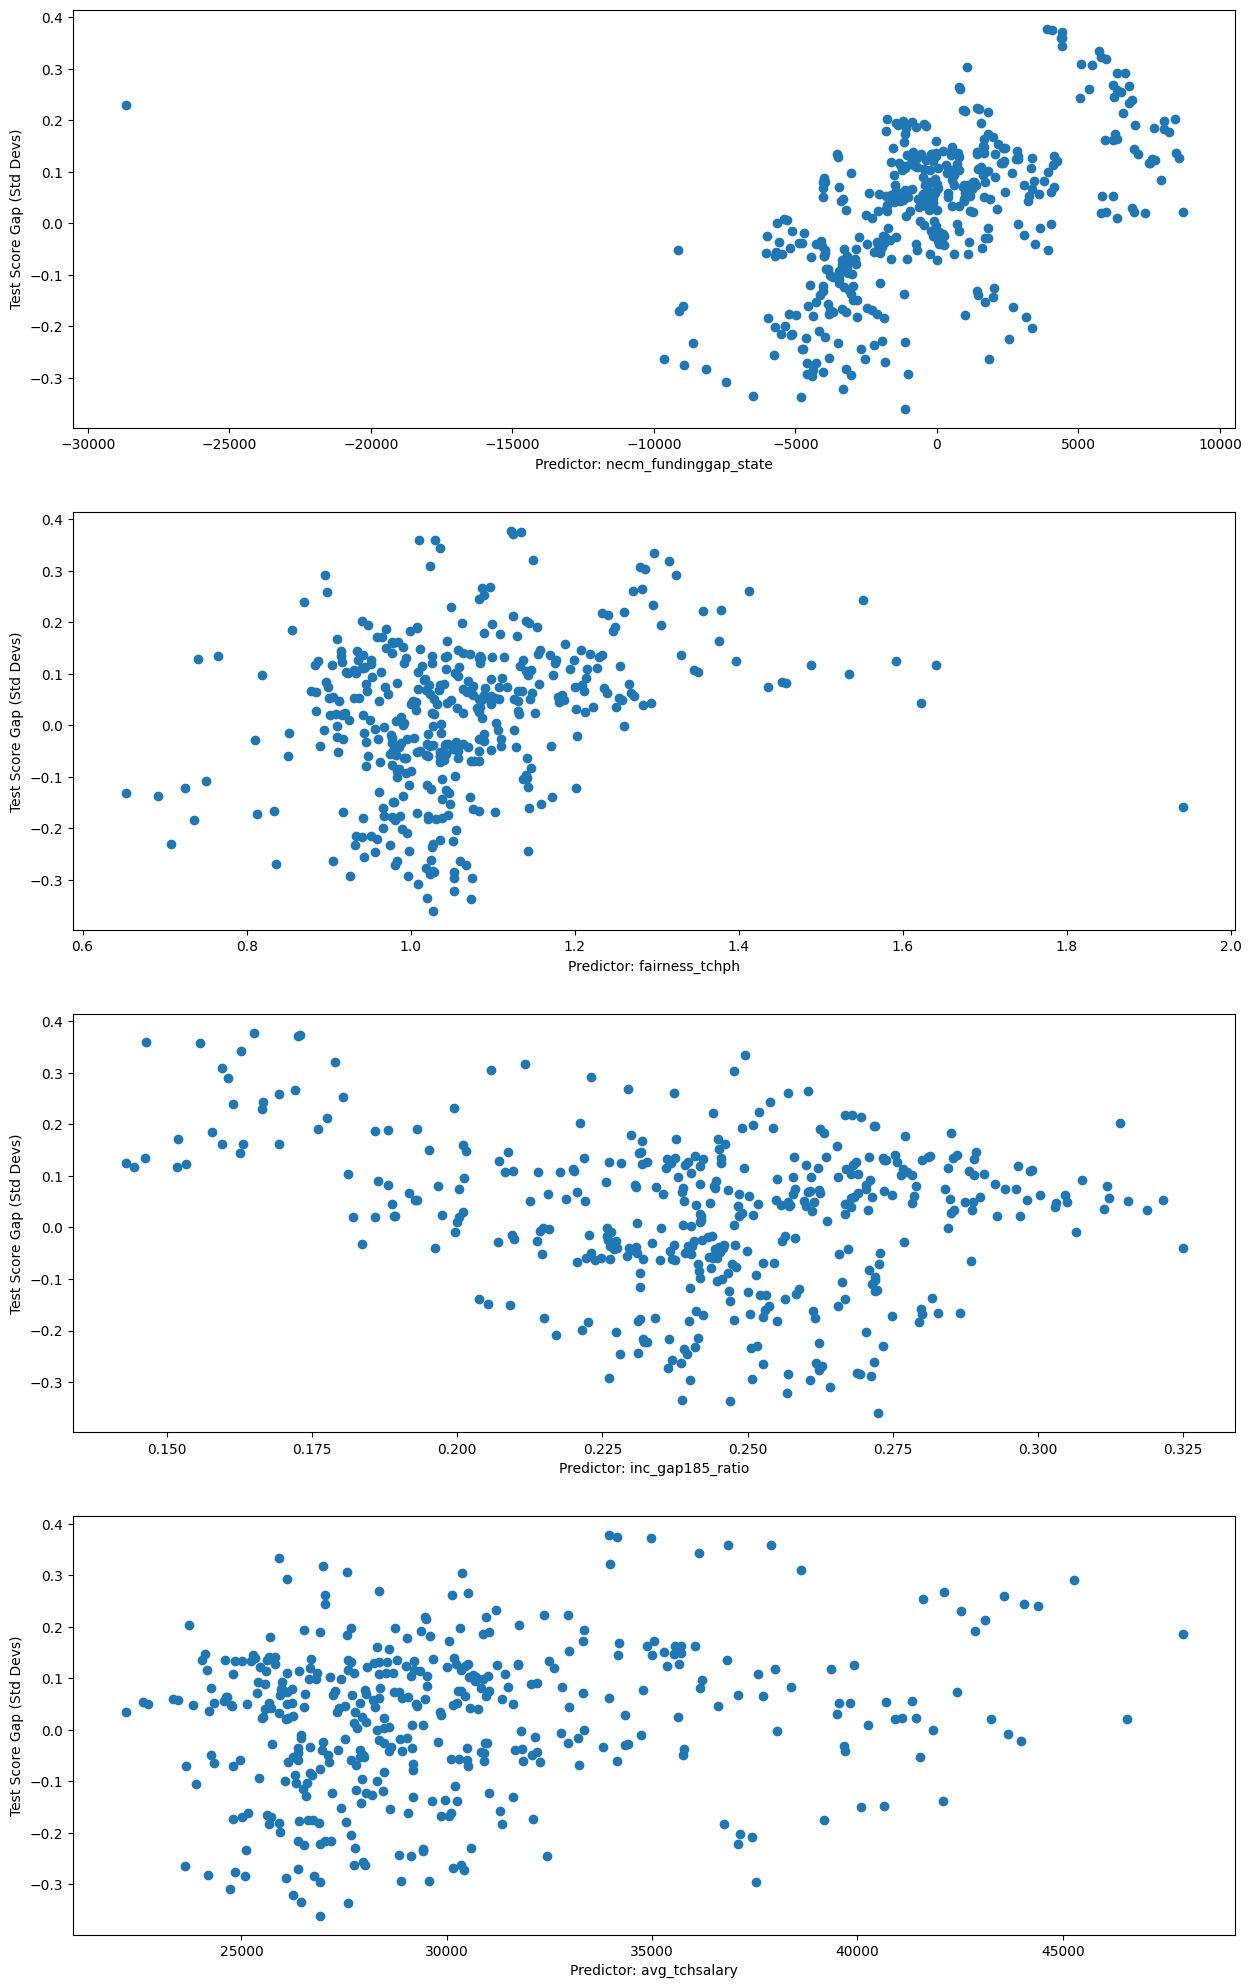

In [115]:
#visualizing our numeric predictors 
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(numeric_predictors, axes.flatten()):
    ax.scatter(X_train[pred], y_train)
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Test Score Gap (Std Devs)")

_Intepretation: Across these plots, the first shows a clear positive relationship. Specfically, that states with higher funding tend to have higher test scores. The second plot shows no clear relationship between fairness in teacher allocation and test scores, suggesting that this predictor is likely not very informative for the outcome. The third plot shows a negative relationship, where states with higher poverty rates tend to have worse test scores, indicating this is an important factor to control for in the regression. Finally, the last plot shows a weak positive relationship, suggesting that higher teacher salaries are only slightly associated with better outcomes._

## **Baseline Multiple Linear Regression Model**

In [116]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
y_hat_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_hat_train)
r2_train = r2_score(y_train, y_hat_train)
print(f"Training MSE: {mse_train}")
print(f"Training R^2: {r2_train}")

Training MSE: 0.010230452857540656
Training R^2: 0.5234689968689208


In [118]:
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns
display(pd.DataFrame({"Coefficients": coefficients, "Predictors": feature_names}))

formula = f"Y = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    formula += f" + {coef:.4f} * {feature_names[i]}"

print("Multiple Linear Regression Formula:")
print(formula)

,Coefficients,Predictors
0,0.000011,necm_fundinggap_state
1,0.215797,fairness_tchph
2,-1.192143,inc_gap185_ratio
3,-0.000007,avg_tchsalary
4,0.053251,east_north_central
5,-0.119994,east_south_central
6,0.113222,mid_atlantic
7,-0.010100,mountain
8,0.084114,new_england
9,-0.056864,pacific


Multiple Linear Regression Formula:
Y = 0.2999 + 0.0000 * necm_fundinggap_state + 0.2158 * fairness_tchph + -1.1921 * inc_gap185_ratio + -0.0000 * avg_tchsalary + 0.0533 * east_north_central + -0.1200 * east_south_central + 0.1132 * mid_atlantic + -0.0101 * mountain + 0.0841 * new_england + -0.0569 * pacific + -0.0188 * south_atlantic + 0.0554 * west_north_central + -0.1003 * west_south_central


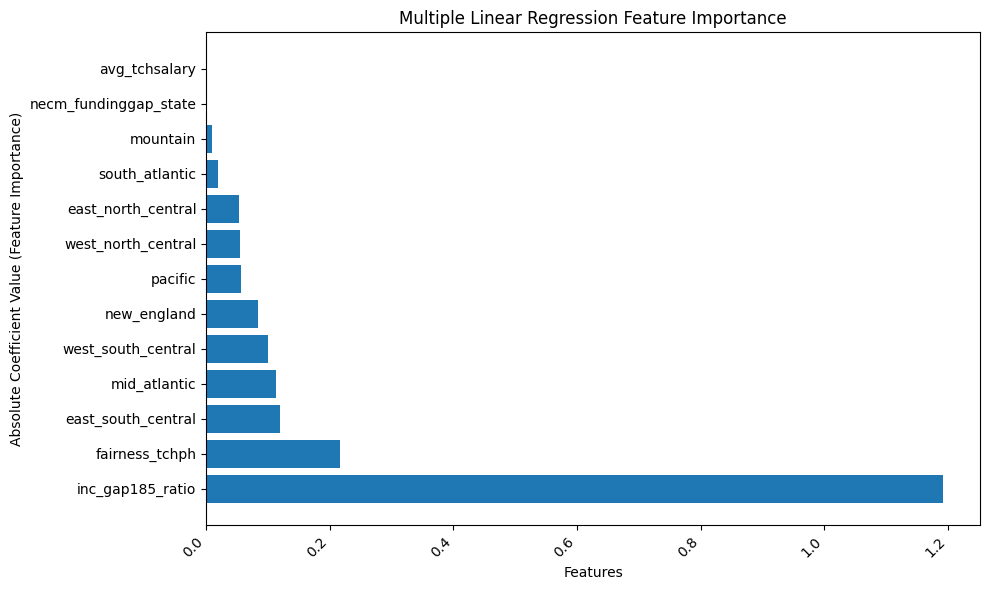

In [119]:
abs_coefficients = np.abs(coefficients)
sorted_indices = np.argsort(abs_coefficients)[::-1]

sorted_abs_coefficients = abs_coefficients[sorted_indices]
sorted_feature_names = [feature_names[i] for i in sorted_indices]

# 4. Create a Feature Importance Graph
plt.figure(figsize=(10, 6))
plt.barh(range(13), sorted_abs_coefficients)
plt.yticks(range(13), sorted_feature_names)
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value (Feature Importance)')
plt.title('Multiple Linear Regression Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Coefficient Interpretation

_According to the absolute values of the features, the region variables have the strongest effects. The Mid-Atlantic region shows the largest positive coefficient, followed by New England, West North Central, and East North Central. The regions with negative coefficients include East South Central, West South Central, and the Pacific region (in absolute descending order). Larger coefficients indicate regions where the model predicts higher student performance. These patterns align with external geographic education rankings, adding some face validity to the results.
In contrast, factors such as the funding gap, fairness of staffing (fairness_tchph), the income gap at the 185% poverty line, and average teacher salary have relatively small coefficients. This suggests that, within a multiple linear regression framework, region is more predictive than the other selected socioeconomic variables. Overall, regional differences dominate the model’s predictive power._

In [120]:
y_hat_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_hat_test)
r2_test = r2_score(y_test, y_hat_test)
print(f"Testing MSE: {mse_test}")
print(f"Testing R^2: {r2_test}")

Testing MSE: 0.010687633351581764
Testing R^2: 0.40920008400480357


### Residual Analysis

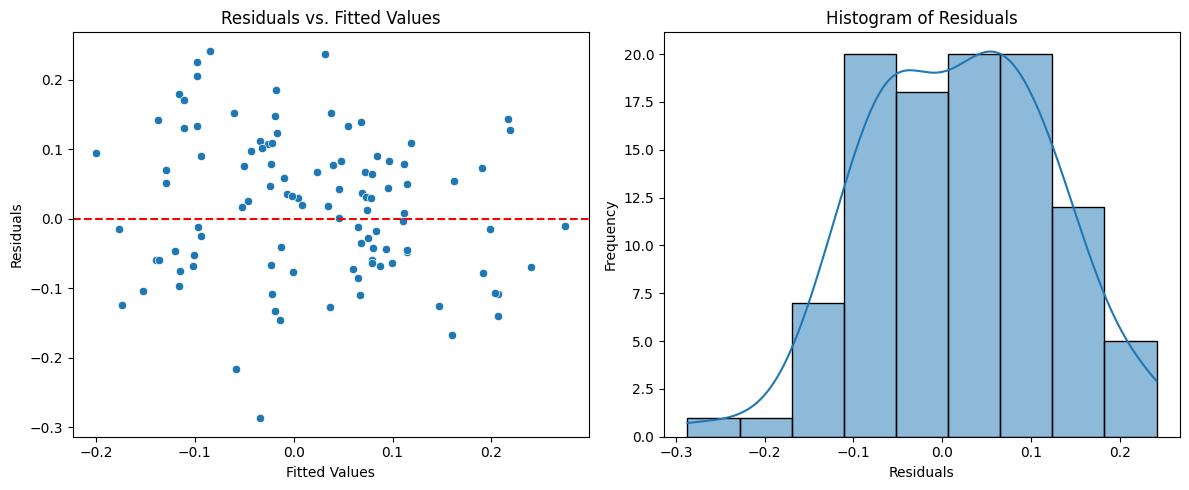

In [121]:
residuals = y_test - y_hat_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Baseline Performance Review

**Train MSE: .0102**, **Train $R^2$: .52347**

**Test MSE: .01068**, **Test $R^2$: .4092**

_With a training $R^2$ of 0.52, our model explains about 52% of the variation in the training data, indicating a moderate fit. When we move from training to test data, we observe the expected decrease in $R^2$ and increase in MSE. However, because the MSE increases only slightly (from 0.01023 to 0.01069), there is minimal evidence of overfitting.
On the test set, the $R^2$ drops to approximately 0.41. This suggests that our model performance is fair but not strong, and that the model may require additional interaction terms to account for the relationships between predictors that this baaseline model is failing to model._

Text(0, 0.5, 'Funding Gap (Dollars)')

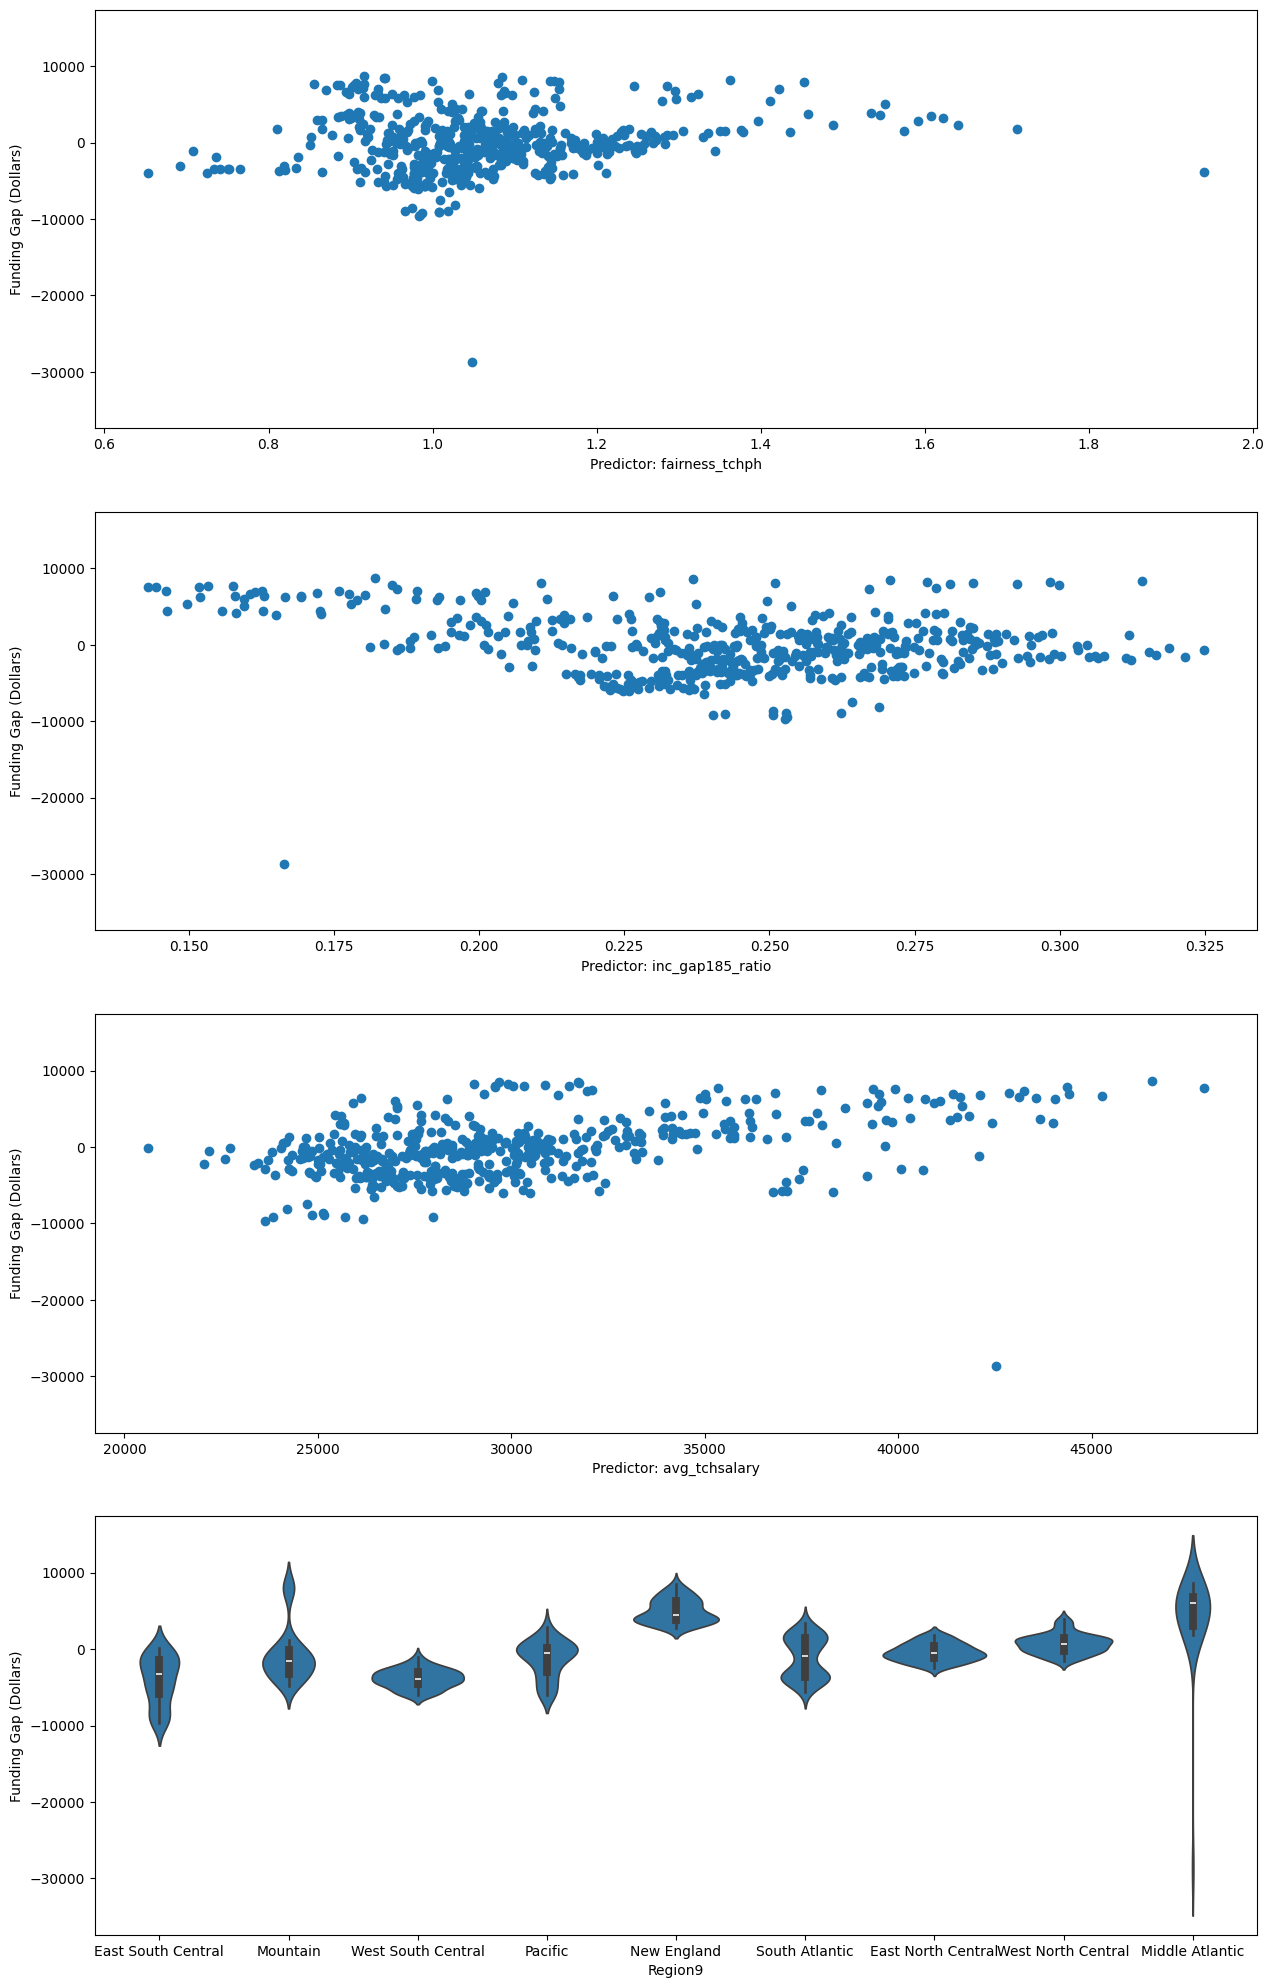

In [122]:
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest[1:4], axes.flatten()[:3]):
    ax.scatter(filtered_df[pred], filtered_df["necm_fundinggap_state"])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Funding Gap (Dollars)")

ax = axes.flatten()[3]
sns.violinplot(x=filtered_df["region9"], y=filtered_df["necm_fundinggap_state"], ax=ax)
ax.set_xlabel("Region9")
ax.set_ylabel("Funding Gap (Dollars)")

### Multiple Linear Regression Model with Interaction Terms

_To improve the baseline model, we can first try to incorporate interaction terms to account for the correlation between necm_fundinggap_state and avg_tchsalary along with the varying relationships between necm_fundinggap_state and regions as necm_fundinggap_state possesses a stronger correlation with our response variable._

In [123]:
primary_var = "necm_fundinggap_state"
other_vars = ["avg_tchsalary","east_north_central", "east_south_central", "mid_atlantic", "mountain",
                "new_england","pacific", "south_atlantic", "west_north_central", "west_south_central"]
int_columns = []

# Creation of interaction terms

for var in other_vars:
    term_name = f"{primary_var}_{var}"
    X_train[term_name] = X_train[primary_var] * X_train[var]
    X_test[term_name] = X_test[primary_var] * X_test[var]
    int_columns.append(term_name)

scaler_interaction = StandardScaler()
X_train[int_columns] = scaler_interaction.fit_transform(X_train[int_columns])
X_test[int_columns] = scaler_interaction.transform(X_test[int_columns])

mlr_int_model = LinearRegression()
mlr_int_model.fit(X_train, y_train)

y_hat_train_int = mlr_int_model.predict(X_train)
mse_train_int = mean_squared_error(y_train, y_hat_train_int)
r2_train_int = r2_score(y_train, y_hat_train_int)
print(f"Training MSE with Interactions: {mse_train_int}")
print(f"Training R^2 with Interactions: {r2_train_int}")


Training MSE with Interactions: 0.008285827543618883
Training R^2 with Interactions: 0.6140489804201082


In [124]:
y_hat_test_int = mlr_int_model.predict(X_test)
mse_test_int = mean_squared_error(y_test, y_hat_test_int)
r2_test_int = r2_score(y_test, y_hat_test_int)
print(f"Testing MSE with Interactions: {mse_test_int}")
print(f"Testing R^2 with Interactions: {r2_test_int}")

Testing MSE with Interactions: 0.008797384455700928
Testing R^2 with Interactions: 0.5136908400177922


In [125]:
print(mlr_int_model.coef_)

[ 2.76456754e-06  1.92556263e-01 -1.32807901e+00 -7.99245544e-06
  4.98032721e-02 -6.16475494e-02  1.52307188e-01  3.77585123e-03
  1.45713752e-01 -3.80804823e-02 -4.25112541e-02  4.99819157e-02
 -2.59342693e-01  1.33218141e-02  8.15732066e-03  3.31130089e-02
 -1.78566887e-02  3.60992703e-02 -1.74156729e-02  1.48529546e-02
 -5.25937519e-03  2.85238535e-03 -3.79103223e-02]


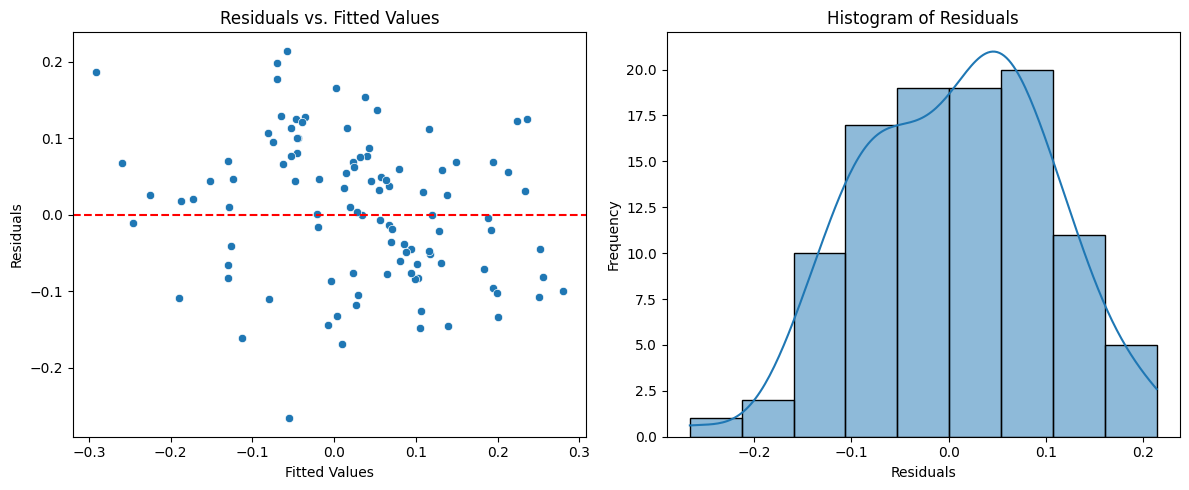

In [126]:
residuals = y_test - y_hat_test_int

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test_int, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

_With the addition of interaction terms, both the training and test MSE decreased further (from ~0.10 to ~0.08), indicating improved predictive performance. At the same time, the test R^2 increased from 0.409 to 0.513, showing that the model now explains 51.3% of the variance._

### Polynomial Model with Interaction Terms (final model)

_While interaction terms improved model performance, there is still unexplained variance, so we fit a polynomial model to test whether performance improves further._ 

In [127]:
degrees = [2, 3, 4, 5]

mean_cv_scores = []
std_cv_scores = []

for degree in degrees:

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    
    model_poly = LinearRegression()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = -cross_val_score(model_poly, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
    
    mean_cv_scores.append(cv_scores.mean())
    std_cv_scores.append(cv_scores.std())

best_degree_cv = degrees[np.argmin(mean_cv_scores)]

print(f"Mean CV MSEs for each degree: {np.round(mean_cv_scores, 2)}")
print(f"Best polynomial degree from CV: {best_degree_cv}")


Mean CV MSEs for each degree: [5.4000000e-01 1.5189900e+03 4.6382901e+05 8.7679766e+05]
Best polynomial degree from CV: 2


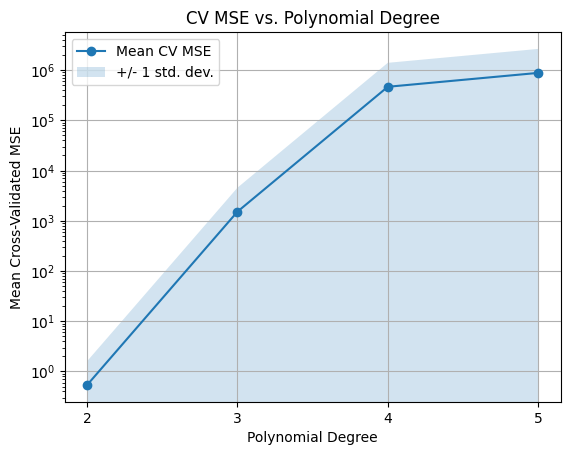

In [128]:
mean_cv_scores = np.array(mean_cv_scores)
std_cv_scores = np.array(std_cv_scores)

plt.plot(degrees, mean_cv_scores, marker='o', label="Mean CV MSE")
plt.fill_between(degrees, np.maximum(0, mean_cv_scores - std_cv_scores), mean_cv_scores + std_cv_scores, alpha=0.2, label="+/- 1 std. dev.")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Cross-Validated MSE")
plt.title("CV MSE vs. Polynomial Degree")
plt.yscale('log')
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

In [129]:
poly = PolynomialFeatures(degree=best_degree_cv, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_hat_train_poly = model_poly.predict(X_train_poly)
mse_train_poly = mean_squared_error(y_train, y_hat_train_poly)
r2_train_poly = r2_score(y_train, y_hat_train_poly)
print(f"Training MSE with Polynomial Degree {best_degree_cv}: {mse_train_poly}")
print(f"Training R^2 with Polynomial Degree {best_degree_cv}: {r2_train_poly}")

Training MSE with Polynomial Degree 2: 0.0031490209077224595
Training R^2 with Polynomial Degree 2: 0.853319680669692


In [130]:
y_hat_test_poly = model_poly.predict(X_test_poly)
mse_test_poly = mean_squared_error(y_test, y_hat_test_poly)
r2_test_poly = r2_score(y_test, y_hat_test_poly)
print(f"Testing MSE with Polynomial Degree {best_degree_cv}: {mse_test_poly}")
print(f"Testing R^2 with Polynomial Degree {best_degree_cv}: {r2_test_poly}")

Testing MSE with Polynomial Degree 2: 0.004959254315580754
Testing R^2 with Polynomial Degree 2: 0.7258582010946046


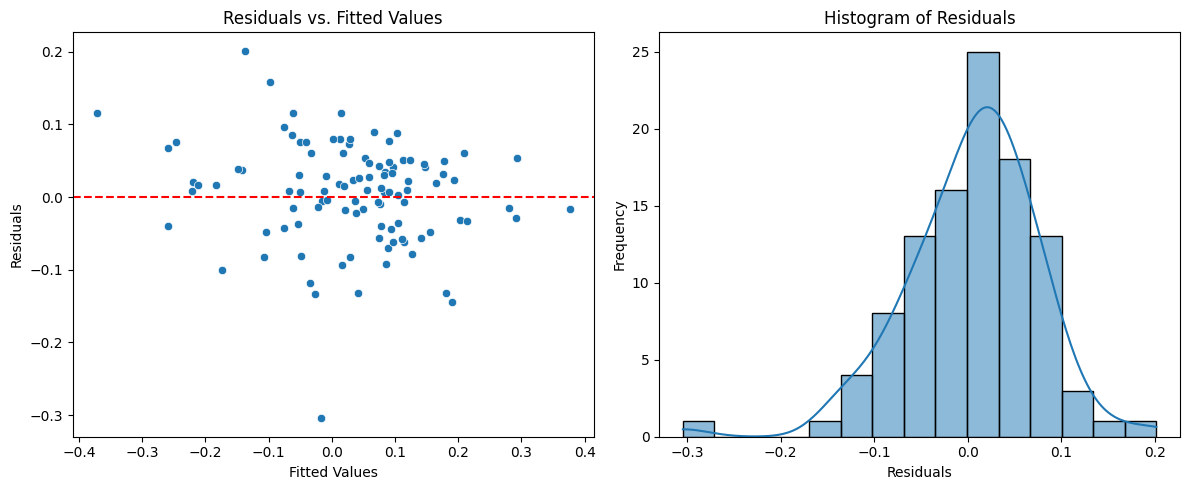

In [131]:
residuals = y_test - y_hat_test_poly

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test_poly, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

_Based on the cross-validation results, the optimal polynomial degree is 2. Relative to the linear interaction model, both the training and test MSE decrease from approximately 0.08 to 0.04, while the test R^2 increases to over 0.70, indicating that a substantial share of the test variance is now explained by the model. Thus, we choose this model as our final one, with the full regression formula below._

In [132]:
intercept_poly = model_poly.intercept_
coefficients_poly = model_poly.coef_
feature_names_poly = poly.get_feature_names_out(X_train.columns)

formula = f"Y = {intercept_poly:.4f}"
for i, coef in enumerate(coefficients_poly):
    formula += f" + {coef:.4f} * {feature_names_poly[i]}"

print("Polynomial Regression Formula:")
print(formula)

Polynomial Regression Formula:
Y = 4.3350 + -0.0015 * necm_fundinggap_state + 0.2594 * fairness_tchph + -15.6611 * inc_gap185_ratio + -0.0001 * avg_tchsalary + -0.1713 * east_north_central + 1.1910 * east_south_central + 0.8391 * mid_atlantic + 0.1842 * mountain + 0.2367 * new_england + -0.1213 * pacific + 0.2048 * south_atlantic + 0.1082 * west_north_central + -2.4713 * west_south_central + -0.0000 * necm_fundinggap_state_avg_tchsalary + 0.0000 * necm_fundinggap_state_east_north_central + 0.0000 * necm_fundinggap_state_east_south_central + 0.0000 * necm_fundinggap_state_mid_atlantic + -0.0000 * necm_fundinggap_state_mountain + 0.0000 * necm_fundinggap_state_new_england + 0.0000 * necm_fundinggap_state_pacific + 0.0000 * necm_fundinggap_state_south_atlantic + -0.0000 * necm_fundinggap_state_west_north_central + 0.0000 * necm_fundinggap_state_west_south_central + 0.0000 * necm_fundinggap_state^2 + 0.0005 * necm_fundinggap_state fairness_tchph + 0.0021 * necm_fundinggap_state inc_gap185_

### Regularized Polynomial Regression

### Random Forest vs. Cross-Validated Random Forest

In [133]:
param_grid = {
    "min_samples_split": [2, 5, 10, 15, 20],
    "max_features": [None, 2, 5, 'sqrt', 'log2'],
    "max_leaf_nodes": [None, 5, 10, 20, 50, 100]
}

random_rf = RandomForestRegressor(random_state=109, n_jobs=-1)

grid_search = GridSearchCV(estimator=random_rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters from Grid Search:")
print(best_params)


Best Hyperparameters from Grid Search:
{'max_features': 2, 'max_leaf_nodes': None, 'min_samples_split': 2}


/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to 

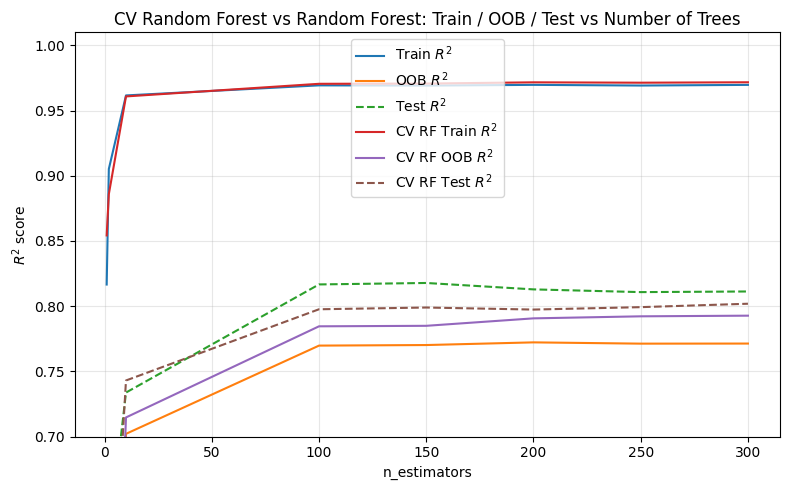

In [138]:
num_estimators = [1, 2, 10, 100, 150, 200, 250, 300]

train_scores_rf_tuned = np.zeros(len(num_estimators))
oob_scores_rf_tuned = np.zeros(len(num_estimators))
test_scores_rf_tuned = np.zeros(len(num_estimators))

train_scores_rf = np.zeros(len(num_estimators))
oob_scores_rf = np.zeros(len(num_estimators))
test_scores_rf = np.zeros(len(num_estimators))

for i, n_estimators in enumerate(num_estimators):
    rf_tuned = RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_split=best_params["min_samples_split"],
        max_features=best_params["max_features"],
        oob_score=True,
        random_state=109,
        n_jobs=-1
    )

    rf_tuned.fit(X_train, y_train)
    
    train_scores_rf_tuned[i] = rf_tuned.score(X_train, y_train)
    oob_scores_rf_tuned[i] = rf_tuned.oob_score_
    test_scores_rf_tuned[i] = rf_tuned.score(X_test, y_test)
    
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        oob_score=True,
        bootstrap=True,
        max_depth=None,
        random_state=109,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    
    train_scores_rf[i] = rf.score(X_train, y_train)
    oob_scores_rf[i] = rf.oob_score_
    test_scores_rf[i] = rf.score(X_test, y_test)

plt.figure(figsize=(8, 5))
xs = num_estimators
plt.plot(xs, train_scores_rf, label="Train $R^2$")
plt.plot(xs, oob_scores_rf,   label="OOB $R^2$")
plt.plot(xs, test_scores_rf,  label="Test $R^2$", linestyle="--")
plt.plot(xs, train_scores_rf_tuned, label="CV RF Train $R^2$")
plt.plot(xs, oob_scores_rf_tuned,   label="CV RF OOB $R^2$")
plt.plot(xs, test_scores_rf_tuned,  label="CV RF Test $R^2$", linestyle="--")

plt.title("CV Random Forest vs Random Forest: Train / OOB / Test vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("$R^2$ score")
plt.ylim(0.7, 1.01)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()